# 02 — Fitting Demo

Walk through the complete fitting pipeline for a single sample:

1. **Data preprocessing**: double referencing, concentration profile c(t)
2. **Direct Kinetics**: closed-form linear solver → initial ka, kd, Rmax
3. **ODE refinement**: 3-phase architecture with multi-start TRF
4. **Fit quality**: overlay model on data, residuals

In [12]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from creoptix_fitting.data_loader import load_cxw
from creoptix_fitting.models import (
    build_concentration_profile, build_pulsed_concentration_profile,
    select_dmso_cal, select_blank,
    double_reference, build_weight_mask, build_full_weight_mask,
    smooth_and_differentiate,
    simulate_sensorgram, is_nonspecific_binder
)
from creoptix_fitting.direct_kinetics import fit_sample as dk_fit_sample
from creoptix_fitting.ode_fitting import fit_sample as ode_fit_sample

CXW = '../20250826_DENV-2 NS2B3 Binding Assay.cxw'
data = load_cxw(CXW)
samples = data['samples']
dmso_cals = data['dmso_cals']
blanks = data['blanks']

def find_sample(name, conc_uM=None):
    """Find a sample by compound name (substring match), optionally filter by concentration.
    If multiple matches, prompts user to choose."""
    hits = [(i, s) for i, s in enumerate(samples) if name in s['compound']]
    if conc_uM is not None:
        hits = [(i, s) for i, s in hits if abs(s['concentration_M'] * 1e6 - conc_uM) < 0.01]
    if not hits:
        raise ValueError(f'No sample found matching "{name}"' + (f' at {conc_uM} µM' if conc_uM else ''))
    if len(hits) == 1:
        return hits[0][1]
    # Multiple matches — ask user to pick
    print(f'Multiple matches for "{name}":')
    for j, (idx, s) in enumerate(hits):
        nsb, _ = is_nonspecific_binder(s)
        tag = ' [NSB]' if nsb else ''
        print(f'  [{j}] samples[{idx}]  {s["compound"]}  {s["concentration_M"]*1e6:.0f} µM  (cycle {s["index"]}){tag}')
    choice = int(input(f'Select [0–{len(hits)-1}]: '))
    return hits[choice][1]

# --- Select sample here ---
sample = find_sample('ASAP-0044216') 
# sample = samples[30]  # or pick by index  
print(f'Sample: {sample["compound"]}  ({sample["concentration_M"]*1e6:.0f} µM, cycle {sample["index"]})')

Multiple matches for "ASAP-0044216":
  [0] samples[0]  ASAP-0044216  25 µM  (cycle 13)
  [1] samples[11]  ASAP-0044216  25 µM  (cycle 37)
  [2] samples[22]  ASAP-0044216  25 µM  (cycle 64)
  [3] samples[27]  ASAP-0044216  25 µM  (cycle 77)
  [4] samples[33]  ASAP-0044216  25 µM  (cycle 91)
  [5] samples[44]  ASAP-0044216  25 µM  (cycle 118)
  [6] samples[55]  ASAP-0044216  25 µM  (cycle 145)
  [7] samples[66]  ASAP-0044216  25 µM  (cycle 172)
Sample: ASAP-0044216  (25 µM, cycle 13)


## 1. Data Preprocessing

### 1a. Double referencing
Subtract nearest preceding blank to remove systematic drift.

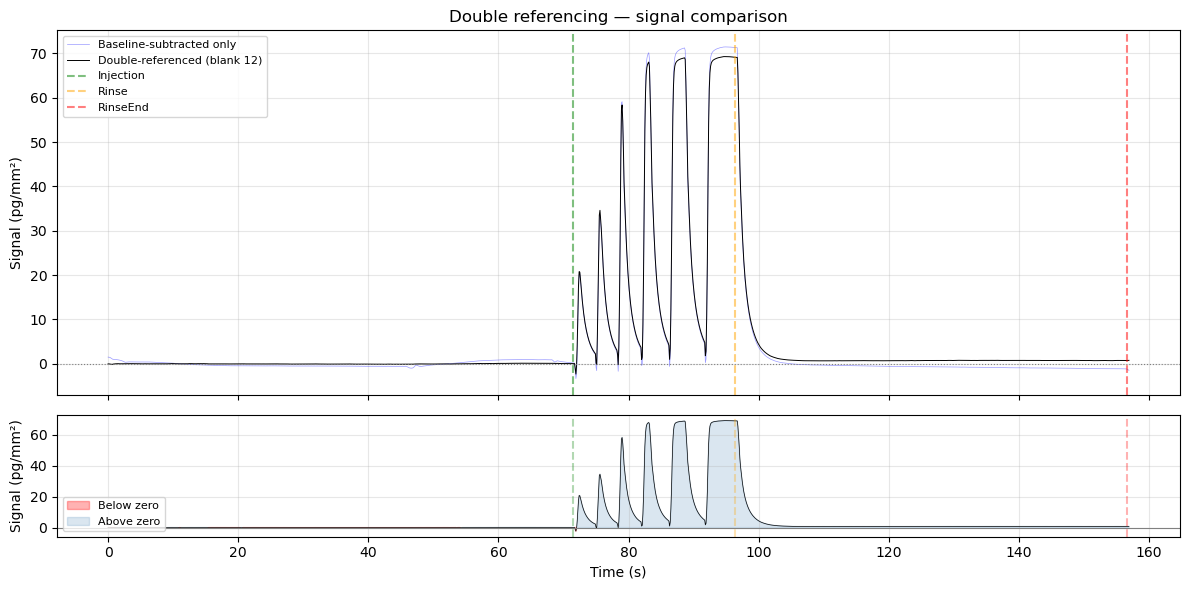

Pre-injection baseline mean: 0.000000 pg/mm² (always 0 by construction)
Signal range: [-2.31, 69.26] pg/mm²
Points below zero: 417/1570 (26.6%)
Dissociation min:  0.66 pg/mm²


In [13]:
t = sample['time']
inj_time = sample['markers'].get('Injection', t[0])
rinse_time = sample['markers'].get('Rinse', t[-1])
rinse_end = sample['markers'].get('RinseEnd', t[-1])

# Baseline-subtracted raw signal (no blank)
bl_mask = t < inj_time
sig_raw = sample['signal'] - sample['signal'][bl_mask].mean()

# Double-referenced signal
sig_dr, blank_idx = double_reference(sample, blanks)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# --- Top: signal comparison ---
axes[0].plot(t, sig_raw, 'b-', lw=0.5, alpha=0.4, label='Baseline-subtracted only')
axes[0].plot(t, sig_dr, 'k-', lw=0.7, label=f'Double-referenced (blank {blank_idx})')
axes[0].axhline(0, color='gray', ls=':', lw=0.8)
for name, col in [('Injection', 'green'), ('Rinse', 'orange'), ('RinseEnd', 'red')]:
    if name in sample['markers']:
        axes[0].axvline(sample['markers'][name], color=col, ls='--', alpha=0.5, label=name)
axes[0].set_ylabel('Signal (pg/mm²)')
axes[0].set_title('Double referencing — signal comparison')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Bottom: highlight where double-ref signal goes negative ---
neg_mask = sig_dr < 0
axes[1].fill_between(t, sig_dr, 0, where=neg_mask, color='red', alpha=0.3, label='Below zero')
axes[1].fill_between(t, sig_dr, 0, where=~neg_mask, color='steelblue', alpha=0.2, label='Above zero')
axes[1].plot(t, sig_dr, 'k-', lw=0.5)
axes[1].axhline(0, color='gray', lw=0.8)
for name, col in [('Injection', 'green'), ('Rinse', 'orange'), ('RinseEnd', 'red')]:
    if name in sample['markers']:
        axes[1].axvline(sample['markers'][name], color=col, ls='--', alpha=0.3)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Signal (pg/mm²)')
axes[1].legend(fontsize=8, loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pct_neg = neg_mask.sum() / len(sig_dr) * 100
print(f'Pre-injection baseline mean: {sig_dr[bl_mask].mean():.6f} pg/mm² (always 0 by construction)')
print(f'Signal range: [{sig_dr.min():.2f}, {sig_dr.max():.2f}] pg/mm²')
print(f'Points below zero: {neg_mask.sum()}/{len(sig_dr)} ({pct_neg:.1f}%)')
print(f'Dissociation min:  {sig_dr[(t >= rinse_time) & (t <= rinse_end)].min():.2f} pg/mm²')

### 1b. Concentration profile c(t)

Two flavours:
- **Envelope c(t)** — rolling-max smoothing removes pulse structure.  Used by Direct Kinetics.
- **Pulsed c(t)** — preserves raw pulse structure (c drops to ≈ 0 during buffer pulses).  Used by ODE fitting so the model can fit the clean buffer-pulse intervals during association.

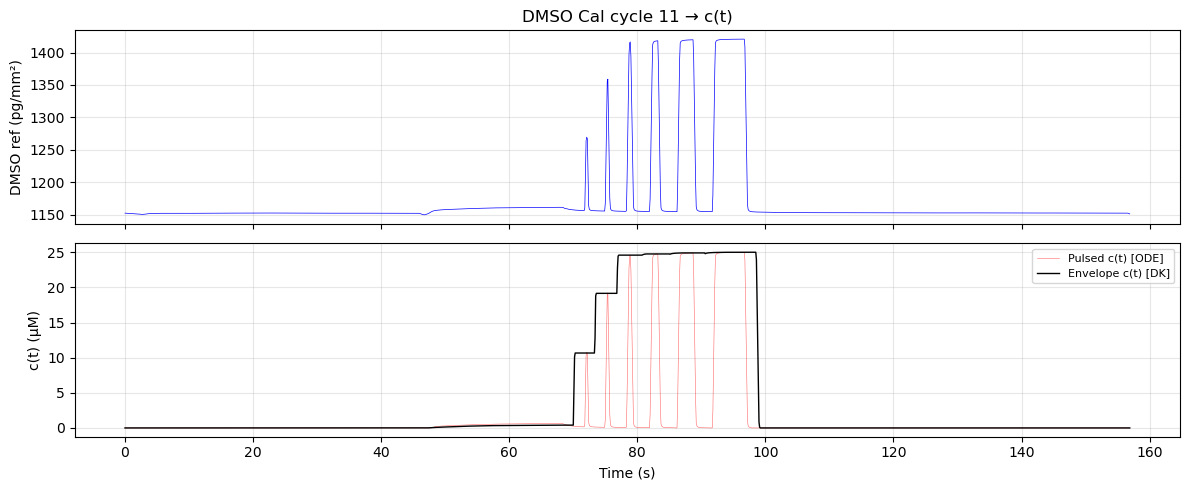

In [14]:
dmso = select_dmso_cal(sample['index'], dmso_cals)
c_func_env, c_raw_env = build_concentration_profile(dmso, sample['concentration_M'])
c_func_pulsed, c_raw_pulsed = build_pulsed_concentration_profile(dmso, sample['concentration_M'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

t_d = dmso['time']
ax1.plot(t_d, dmso['raw_reference'], 'b-', lw=0.5)
ax1.set_ylabel('DMSO ref (pg/mm²)')
ax1.set_title(f'DMSO Cal cycle {dmso["index"]} → c(t)')
ax1.grid(True, alpha=0.3)

ax2.plot(t_d, c_raw_pulsed * 1e6, 'r-', lw=0.4, alpha=0.6, label='Pulsed c(t) [ODE]')
ax2.plot(t_d, c_raw_env * 1e6, 'k-', lw=1.0, label='Envelope c(t) [DK]')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('c(t) (µM)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Direct Kinetics — Closed-form Linear Solver

Fits the full sensorgram using the reparameterised Langmuir ODE:

$$\frac{dR}{dt} = k_1 c(t) - k_2 c(t) R(t) - k_3 R(t)$$

where $(k_1, k_2, k_3) = (k_a R_{max},\; k_a,\; k_d)$.

In [15]:
dk = dk_fit_sample(sample, dmso_cals, blanks=blanks)

print('=== Direct Kinetics Results ===')
print(f'  ka   = {dk["ka"]:.2e} M⁻¹s⁻¹')
print(f'  kd   = {dk["kd"]:.4f} s⁻¹')
print(f'  Rmax = {dk["Rmax"]:.1f} pg/mm²')
print(f'  KD   = {dk["KD"]*1e6:.2f} µM')
print(f'  R0   = {dk["R0_dissoc"]:.1f} pg/mm² (at rinse)')
print(f'  σ    = {dk["sigma_residual"]:.3f} pg/mm²')

=== Direct Kinetics Results ===
  ka   = 3.75e+05 M⁻¹s⁻¹
  kd   = 0.4931 s⁻¹
  Rmax = 72.9 pg/mm²
  KD   = 1.32 µM
  R0   = 69.2 pg/mm² (at rinse)
  σ    = 3.996 pg/mm²


In [16]:
def _contiguous_spans(t, mask):
    """Yield (start, end) time spans for contiguous True runs in mask."""
    spans = []
    in_span = False
    for i, v in enumerate(mask):
        if v and not in_span:
            start = t[i]
            in_span = True
        elif not v and in_span:
            spans.append((start, t[i - 1]))
            in_span = False
    if in_span:
        spans.append((start, t[-1]))
    return spans

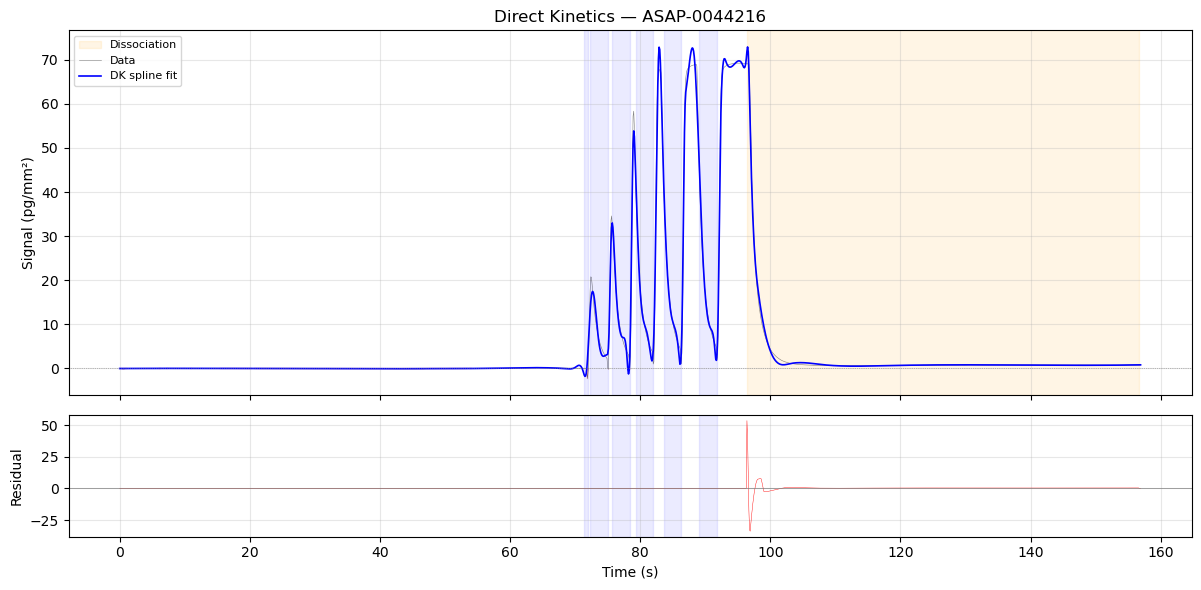

In [17]:
# Plot DK smoothed fit vs data
t_dk = dk['t']
sig_dk = dk['signal']
R_smooth = dk['R_smooth']
w_dk = build_weight_mask(t_dk, sample['markers'])

# Full weight mask to show buffer-pulse intervals (for reference)
w_full = build_full_weight_mask(t_dk, sample['markers'], dmso)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Shade all fitted regions (buffer pulses + dissociation)
buf_mask = (w_full > 0) & (w_dk == 0)
for start, end in _contiguous_spans(t_dk, buf_mask):
    axes[0].axvspan(start, end, alpha=0.08, color='blue')
    axes[1].axvspan(start, end, alpha=0.08, color='blue')
axes[0].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange', label='Dissociation')

# Shade negative regions of data
neg_dk = sig_dk < 0
axes[0].fill_between(t_dk, sig_dk, 0, where=neg_dk, color='red', alpha=0.15)

axes[0].plot(t_dk, sig_dk, 'k-', lw=0.4, alpha=0.5, label='Data')
axes[0].plot(t_dk, R_smooth, 'b-', lw=1.2, label='DK spline fit')
axes[0].axhline(0, color='gray', ls=':', lw=0.5)
axes[0].set_ylabel('Signal (pg/mm²)')
axes[0].set_title(f'Direct Kinetics — {sample["compound"]}')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_dk, dk['residuals'], 'r-', lw=0.3)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. ODE Refinement — Multi-start TRF

Three-phase architecture:
1. **Phase 1**: Closed-form linear regression for $R_0, R_{ss}$ using $k_d$ from DK
2. **Phase 2**: Derive $k_a$ from steady-state at dissociation onset
3. **Phase 3**: Multi-start TRF optimising $(k_a, R_{max})$ with $k_d$ fixed

Median aggregation over converged starts.

In [18]:
ode = ode_fit_sample(sample, dmso_cals, blanks=blanks)

print('=== ODE Refinement Results ===')
print(f'  ka   = {ode["ka"]:.2e} M⁻¹s⁻¹  (DK: {ode["dk_ka"]:.2e})')
print(f'  kd   = {ode["kd"]:.4f} s⁻¹      (DK: {ode["dk_kd"]:.4f})')
print(f'  Rmax = {ode["Rmax"]:.1f} pg/mm²   (DK: {ode["dk_Rmax"]:.1f})')
print(f'  KD   = {ode["KD"]*1e6:.2f} µM     (DK: {ode["dk_KD"]*1e6:.2f})')
print(f'  R0   = {ode["R0"]:.1f},  Rss = {ode["Rss"]:.2f} pg/mm²')
print(f'  σ    = {ode["sigma_residual"]:.3f} pg/mm²')
print(f'  {ode["message"]}')
if not np.isnan(ode.get('ka_se', np.nan)):
    print(f'  ka SE  = {ode["ka_se"]:.2e}')
    print(f'  Rmax SE = {ode["Rmax_se"]:.2f}')

=== ODE Refinement Results ===
  ka   = 6.50e+04 M⁻¹s⁻¹  (DK: 3.75e+05)
  kd   = 0.4931 s⁻¹      (DK: 0.4931)
  Rmax = 51.7 pg/mm²   (DK: 72.9)
  KD   = 7.59 µM     (DK: 1.32)
  R0   = 22.4,  Rss = 0.58 pg/mm²
  σ    = 3.728 pg/mm²
  3/3 ODE starts converged
  ka SE  = 5.57e+03
  Rmax SE = 1.73


Weighted points: 750 total  (147 buffer pulses + 603 dissociation)


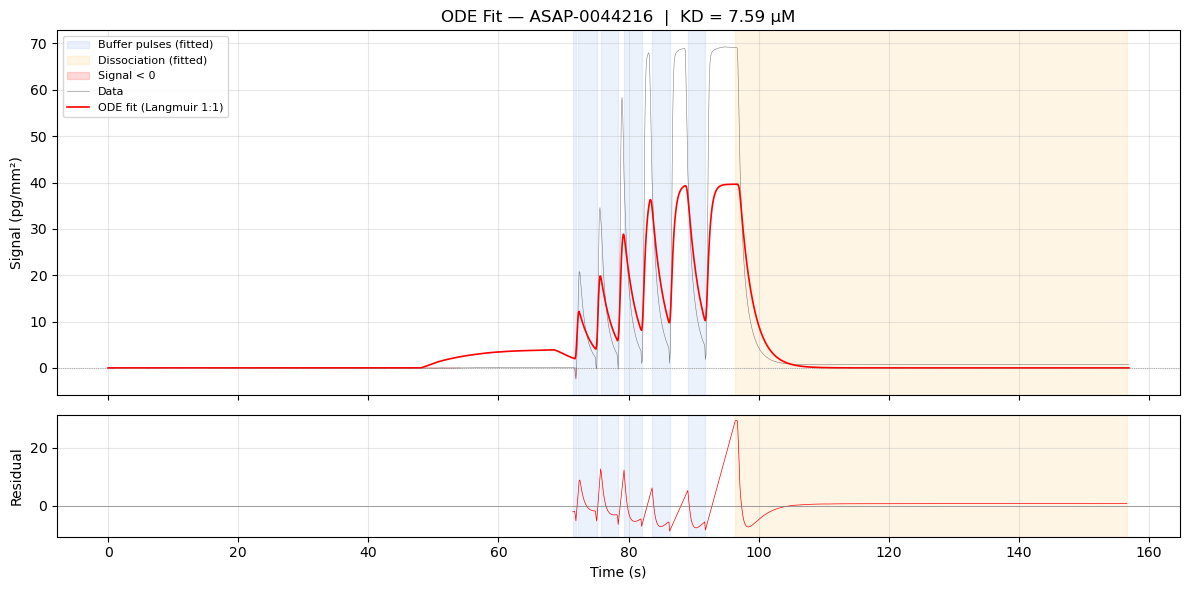

In [19]:
# Overlay ODE fit on data — full sensorgram with all weighted regions
t_ode = ode['t']
sig_ode = ode['signal']
R_fit = ode['R_fit']

# Full weight mask (buffer pulses during association + dissociation)
w_ode = build_full_weight_mask(t_ode, sample['markers'], dmso)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Shade all fitted regions
buf_mask = (w_ode > 0) & (t_ode < rinse_time)
dissoc_mask_plot = (t_ode >= rinse_time) & (t_ode <= rinse_end)

for start, end in _contiguous_spans(t_ode, buf_mask):
    axes[0].axvspan(start, end, alpha=0.12, color='cornflowerblue')
    axes[1].axvspan(start, end, alpha=0.12, color='cornflowerblue')
axes[0].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange')
axes[1].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange')

# Legend entries for shading
axes[0].fill_between([], [], alpha=0.12, color='cornflowerblue', label='Buffer pulses (fitted)')
axes[0].fill_between([], [], alpha=0.1, color='orange', label='Dissociation (fitted)')

# Shade negative regions of data
neg_ode = sig_ode < 0
axes[0].fill_between(t_ode, sig_ode, 0, where=neg_ode, color='red', alpha=0.15,
                     label='Signal < 0')

axes[0].plot(t_ode, sig_ode, 'k-', lw=0.4, alpha=0.5, label='Data')
axes[0].plot(t_ode, R_fit, 'r-', lw=1.2, label='ODE fit (Langmuir 1:1)')
axes[0].axhline(0, color='gray', ls=':', lw=0.5)
axes[0].set_ylabel('Signal (pg/mm²)')
axes[0].set_title(f'ODE Fit — {sample["compound"]}  |  '
                  f'KD = {ode["KD"]*1e6:.2f} µM')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Residuals for all weighted points (buffer pulses + dissociation)
residuals_full = ode['residuals']
weighted_mask = w_ode > 0
axes[1].plot(t_ode[weighted_mask], residuals_full[weighted_mask], 'r-', lw=0.5)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

n_buf = buf_mask.sum()
n_dissoc = dissoc_mask_plot.sum()
n_total = weighted_mask.sum()
print(f'Weighted points: {n_total} total  ({n_buf} buffer pulses + {n_dissoc} dissociation)')

plt.tight_layout()
plt.show()

## 4. DK vs ODE Comparison

Full sensorgram overlay + dissociation zoom.  The ODE fit uses pulsed c(t) and is weighted on buffer pulses + dissociation, so it should track the clean intervals during association too.

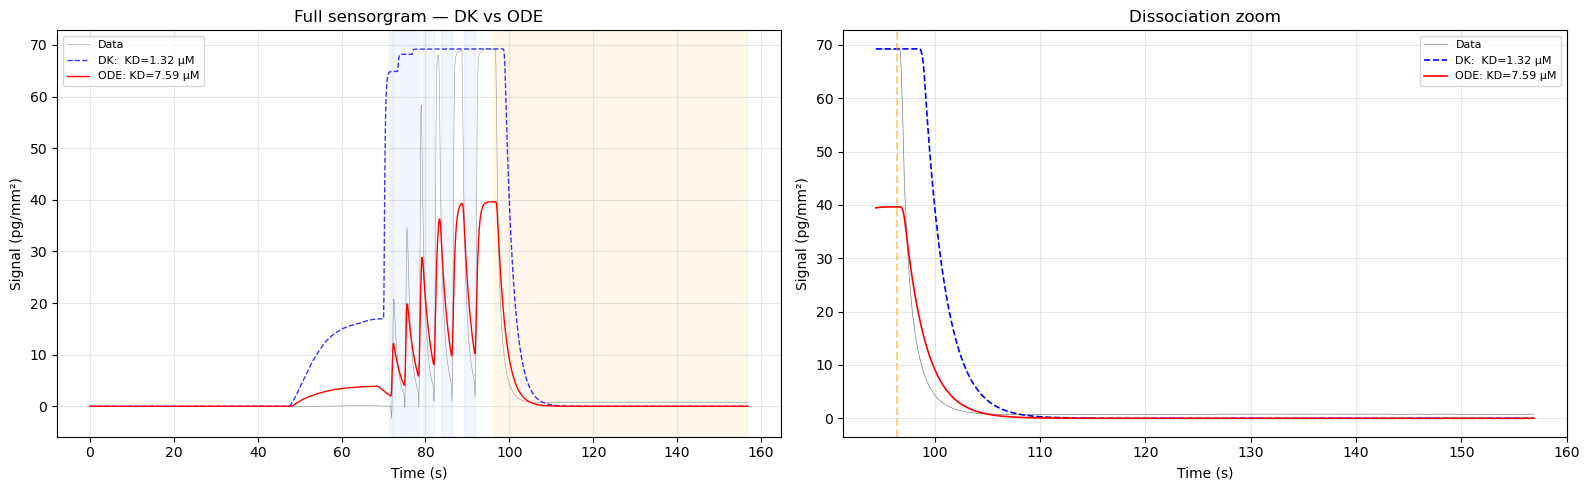

In [20]:
# Simulate DK model for comparison (uses envelope c(t))
R_dk_sim = simulate_sensorgram(t_dk, dk['ka'], dk['kd'], dk['Rmax'],
                                dk['c_func'], R0=0.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Full sensorgram ---
ax = axes[0]
# Shade buffer pulses
w_full = build_full_weight_mask(t_ode, sample['markers'], dmso)
buf_mask_full = (w_full > 0) & (t_ode < rinse_time)
for start, end in _contiguous_spans(t_ode, buf_mask_full):
    ax.axvspan(start, end, alpha=0.08, color='cornflowerblue')
ax.axvspan(rinse_time, rinse_end, alpha=0.08, color='orange')

ax.plot(t_dk, sig_dk, 'k-', lw=0.4, alpha=0.4, label='Data')
ax.plot(t_dk, R_dk_sim, 'b--', lw=1.0, alpha=0.8,
        label=f'DK:  KD={dk["KD"]*1e6:.2f} µM')
ax.plot(t_ode, R_fit, 'r-', lw=1.0,
        label=f'ODE: KD={ode["KD"]*1e6:.2f} µM')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Signal (pg/mm²)')
ax.set_title('Full sensorgram — DK vs ODE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: Dissociation zoom ---
ax = axes[1]
d_mask = (t_dk >= rinse_time - 2) & (t_dk <= rinse_end + 2)
ax.plot(t_dk[d_mask], sig_dk[d_mask], 'k-', lw=0.5, alpha=0.5, label='Data')
ax.plot(t_dk[d_mask], R_dk_sim[d_mask], 'b--', lw=1.2,
        label=f'DK:  KD={dk["KD"]*1e6:.2f} µM')
ax.plot(t_ode[d_mask], R_fit[d_mask], 'r-', lw=1.2,
        label=f'ODE: KD={ode["KD"]*1e6:.2f} µM')
ax.axvline(rinse_time, color='orange', ls='--', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Signal (pg/mm²)')
ax.set_title('Dissociation zoom')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()